In [1]:
###the folllowing libraries will be neeeded
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import warnings
warnings.filterwarnings('ignore')

In [2]:
class fault:
    def __init__(self, Sv, S_hmax, S_hmin,Pp,mu,azimuth_shmin,azimuth_shmax,PR,Pw):
        self.Sv=Sv
        self.S_hmax=S_hmax
        self.S_hmin=S_hmin
        self.Pp=Pp
        self.PR=PR
        self.Pw=Pw
        self.mu=mu
        self.azimuth_shmin=azimuth_shmin
        self.azimuth_shmax=azimuth_shmax
        
def TypeFaulting(fault):
        if fault.Sv>fault.S_hmax and fault.Sv>fault.S_hmin:
            fault_regime=['normal']
            S1=fault.Sv
            S2=fault.S_hmax
            S3=fault.S_hmin
        elif fault.S_hmax>fault.Sv and fault.S_hmin>fault.Sv:
            fault_regime=['reverse']
            S1=fault.S_hmax
            S2=fault.S_hmin
            S3=fault.Sv
        elif fault.S_hmax>fault.Sv and fault.Sv>fault.S_hmin:
            fault_regime=['strike']
            S1=fault.S_hmax
            S2=fault.Sv
            S3=fault.S_hmin
        fault.S1=S1
        fault.S2=S2
        fault.S3=S3
        fault.fault_regime=fault_regime
        return fault.fault_regime

**TESTING**

In [30]:
#inisiasi describe stress state (Sv, S_hmax, S_hmin,Pp,mu,azimuth_shmin, azimuth_shmax,PR, Pw)
Fault = fault(30, 25, 20, 32, 0.8, 0, 90, 0.3, 32)
TypeFaulting(Fault)

['normal']

# TENSOR

In [31]:
def angle_transform(fault):
    fault_regime=fault.fault_regime;azimuth_shmax=fault.azimuth_shmax;
    azimuth_shmin=fault.azimuth_shmin
    if fault_regime==['normal']:
        a=azimuth_shmin/180*np.pi; #convert to radians
        b=np.pi/2;
        y=0;
    elif fault_regime==['strike']:
        a=azimuth_shmax/180*np.pi;
        b=0;
        y=np.pi/2;
    elif fault_regime==['reverse']:
        a=azimuth_shmax/180*np.pi ;   #convert to radians
        b=0;
        y=0;
    fault.a=a;fault.b=b;fault.y=y
    return fault.a,fault.b,fault.y

**TESTING**

In [32]:
angle_transform(Fault)

(0.0, 1.5707963267948966, 0)

In [35]:
def Matrix_transforms(fault):
    S1=fault.S1; S2=fault.S2; S3=fault.S3; a=fault.a; b=fault.b; y=fault.y
    S_p=np.matrix([[S1,0,0],
                   [0,S2,0],
                   [0,0,S3]])
    
    Rpg=np.array([[np.cos(a)*np.cos(b), np.sin(a)*np.cos(b), -1*np.sin(b)],
               [np.cos(a)*np.sin(b)*np.sin(y)-np.sin(a)*np.cos(y), np.sin(a)*np.sin(b)*np.sin(y)+np.cos(a)*np.cos(y), np.cos(b)*np.sin(y)],
               [np.cos(a)*np.sin(b)*np.cos(y)+np.sin(a)*np.sin(y), np.sin(a)*np.sin(b)*np.cos(y)-np.cos(a)*np.sin(y), np.cos(b)*np.cos(y)]])
    
    Rpg=np.matrix.round(Rpg,3)
    Sg=Rpg.transpose() @ S_p @ Rpg
    fault.Sg=np.matrix.round(Sg,3)
    fault.Rpg=Rpg
    fault.S_p=S_p
    return fault.S_p,fault.Rpg,fault.Sg

**TESTING**

SG adalah hasil konversi dari arah Principal (Sp) jadi Geographic Coordinate (Sg)

In [38]:
Matrix_transforms(Fault)

(matrix([[30,  0,  0],
         [ 0, 25,  0],
         [ 0,  0, 20]]),
 array([[ 0.,  0., -1.],
        [ 0.,  1.,  0.],
        [ 1.,  0.,  0.]]),
 array([[20.,  0.,  0.],
        [ 0., 25.,  0.],
        [ 0.,  0., 30.]]))

In [277]:
def new_cordinates(azi,inc,fault):
    s=azi/180*np.pi
    d=inc/180*np.pi
    Rgw=np.array([[-1*np.cos(s)*np.cos(d), -1*np.sin(s)*np.cos(d), np.sin(d)],
           [np.sin(s), -1*np.cos(s), 0],
           [np.cos(s)*np.sin(d), np.sin(s)*np.sin(d), np.cos(d)]])
    Sw =Rgw @ fault.Rpg.transpose() @ fault.S_p @ fault.Rpg @ Rgw.transpose()
    fault.Sw= Sw #np.matrix.round(Sw,3)
    return fault.Sw

**TESTING**

Stress di Near-Wellbore

In [181]:
new_cordinates(0,0,Fault)

matrix([[47.598588,  7.07256 ,  0.      ],
        [ 7.07256 , 64.46458 ,  0.      ],
        [ 0.      ,  0.      , 70.      ]])

# UCS REQUIRED

import numpy as np

def UCS_analisis(azi,inc,fault):
    t = np.linspace(0, 2 * np.pi, 360)
    q = (1 + np.sin(fault.mu)) / (1 - np.sin(fault.mu))  # Perhatikan perubahan angle di sini

    Srr_values = []
    Stmin_values = []
    Stmax_values = []
    UCS_values = []

    for angle in t:
        angle_transform(fault)
        Matrix_transforms(fault)
        new_cordinates(azi, inc, fault)  # Perhatikan perubahan sudut angle di sini
        S11 = fault.Sw[0, 0] - fault.Pp
        S22 = fault.Sw[1, 1] - fault.Pp
        S33 = fault.Sw[2, 2] - fault.Pp
        dP = fault.Pw - fault.Pp
        Srr = dP
        Stt = S11 + S22 - 2 * (S11 - S22) * np.cos(2 * angle) - 4 * fault.Sw[0, 1] * np.sin(2 * angle) - dP
        Szz = S33 - 2 * fault.PR * (S11 - S22) * np.cos(2 * angle) - 4 * fault.PR * fault.Sw[0, 1] * np.sin(2 * angle)
        Stz = 2 * (fault.Sw[1, 2] * np.cos(angle) - fault.Sw[0, 2] * np.sin(angle))

        Stmax = ((Szz + Stt) / 2) + np.sqrt((((Szz - Stt) / 2) ** 2) + Stz ** 2)
        Stmin = ((Szz + Stt) / 2) - np.sqrt((((Szz - Stt) / 2) ** 2) + Stz ** 2)
        UCS = Stmax - q * Srr

        Srr_values.append(Srr)
        Stmin_values.append(Stmin)
        Stmax_values.append(Stmax)
        UCS_values.append(UCS)

    return UCS_values, Srr_values, Stmin_values, Stmax_values

import numpy as np
import matplotlib.pyplot as plt


# Inisialisasi Stress Regime (Sv,Shmax,Shmin,Pp,Fang Mu, Shmin azi, PR, Pw)
Fault = fault(68.2, 57, 55, 46.8, 0.8, 160, 0.2, 46.8)
TypeFaulting(Fault)


# Memanggil fungsi UCS_analisis (Azi well, Inc Well, Fault)
UCS_vals, Srr_vals, Stmin_vals, Stmax_vals = UCS_analisis(0,0,Fault)

# Membuat array theta dari 0 hingga 360 derajat
theta = np.linspace(0, 360, len(UCS_vals))

# Membuat plot
plt.figure(figsize=(10, 6))
#plt.plot(theta, UCS_vals, label='UCS', color='blue')
plt.plot(theta, Srr_vals, label='Srr', color='red')
plt.plot(theta, Stmin_vals, label='Stmin', color='green')
plt.plot(theta, Stmax_vals, label='Stmax', color='purple')

plt.title('Plot UCS, Srr, Stmin, dan Stmax terhadap Theta')
plt.xlabel('Theta (derajat)')
plt.ylabel('Nilai')
plt.grid(True)
plt.legend()
plt.show()

# COBA COBA ACAKAN (INI YANG BENER, DIPAKE)

# Plotting Srr, Stt, Szz

In [342]:
import numpy as np

def UCS_analisis(azi,inc,fault):
    t = np.linspace(0,2*np.pi,num=360)
    TypeFaulting(fault)
    angle_transform(fault)
    Matrix_transforms(fault)
    new_cordinates(azi, inc, fault)
    
    # Perhatikan perubahan angle di sini
    #q = (np.sqrt((fault.mu**2)+1)+fault.mu)**2
    q = (1 + np.sin(fault.mu)) / (1 - np.sin(fault.mu))
    
    S11 = fault.Sw[0, 0] - fault.Pp
    S22 = fault.Sw[1, 1] - fault.Pp
    S33 = fault.Sw[2, 2] - fault.Pp

    Srr_values = []
    Stt_values = []
    Szz_values = []
    UCS_values = []

    for angle in t:
        dP = fault.Pw - fault.Pp
        Srr = dP
        Stt = S11 + S22 - 2 * (S11 - S22) * np.cos(2 * angle) - 4 * fault.Sw[0, 1] * np.sin(2 * angle) - dP
        Szz = S33 - 2 * fault.PR * (S11 - S22) * np.cos(2 * angle) - 4 * fault.PR * fault.Sw[0, 1] * np.sin(2 * angle)
        Stz = 2 * (fault.Sw[1, 2] * np.cos(angle) - fault.Sw[0, 2] * np.sin(angle))

        Stmax = 0.5 * (Szz + Stt + np.sqrt((Szz - Stt)**2 + 4 * (Stz**2)))
        Stmin = 0.5 * (Szz + Stt - np.sqrt((Szz - Stt)**2 + 4 * (Stz**2)))
        

        #UCS = (max(Stt, Szz, Srr) - (q * min(Stt, Szz, Srr))) + fault.Pp
        UCS = Stmax - q * Srr

        Srr_values.append(Srr)
        Stt_values.append(Stt)
        Szz_values.append(Szz)
        UCS_values.append(UCS)

    return UCS_values, Srr_values, Stt_values, Szz_values

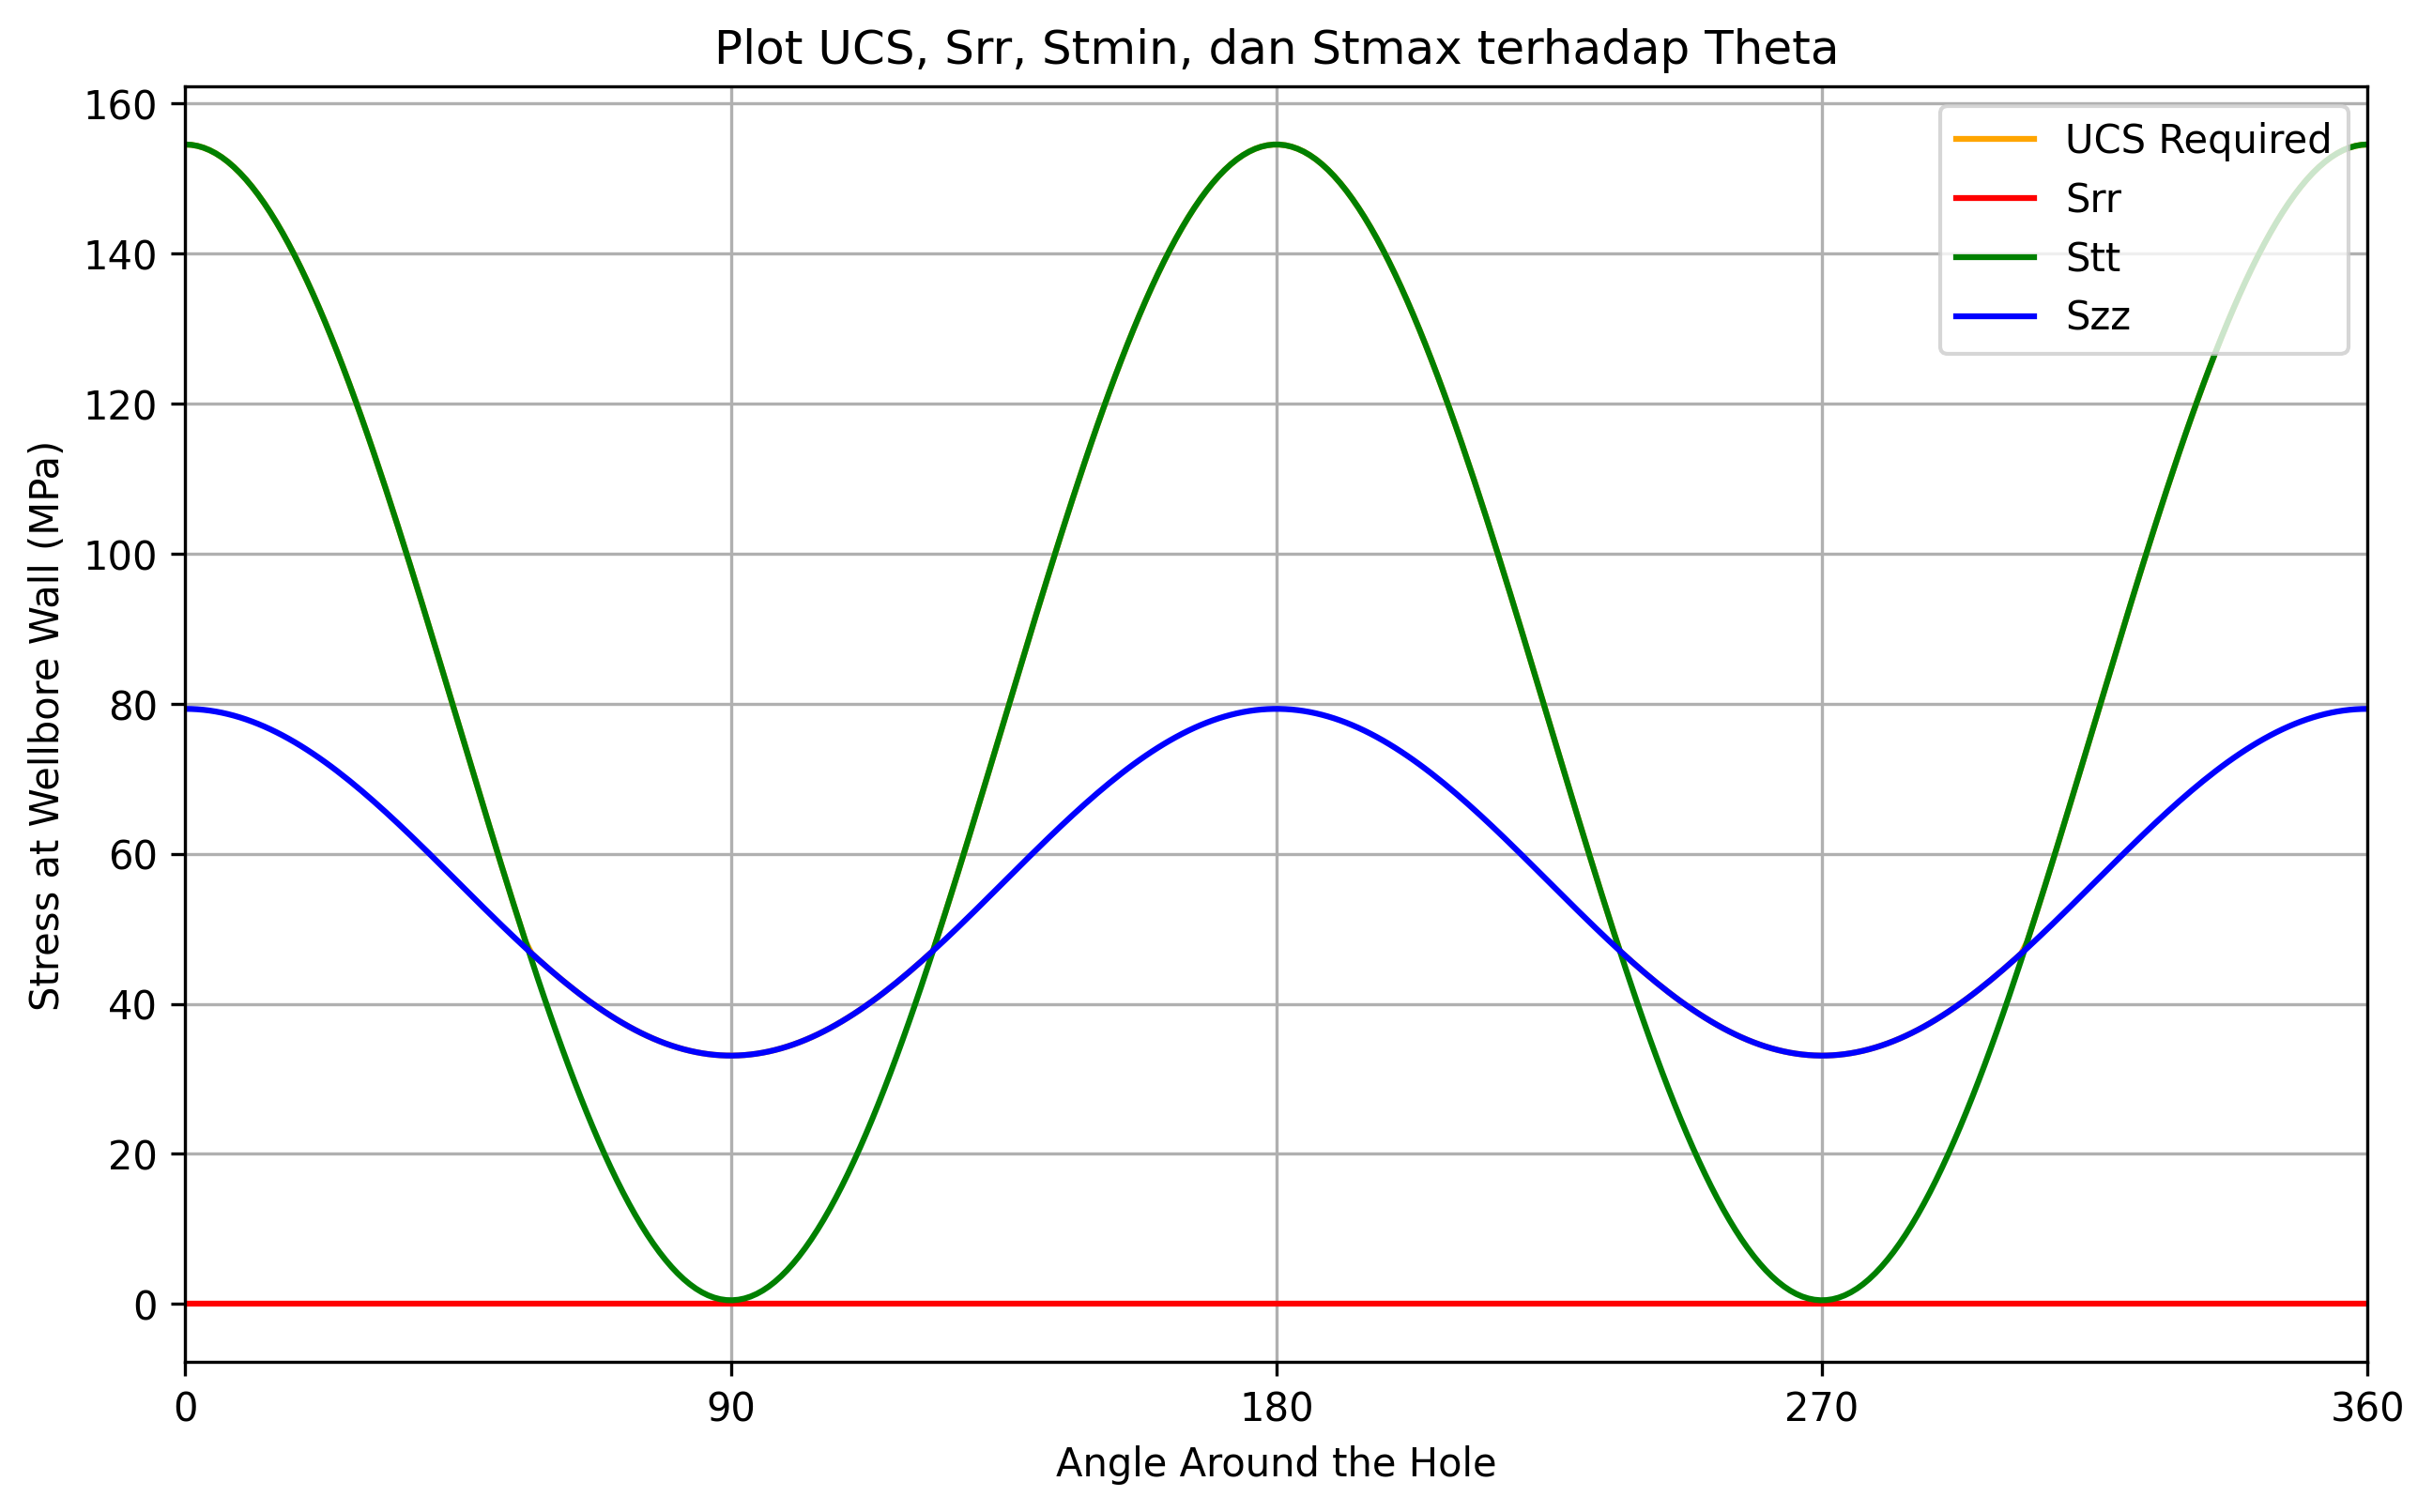

In [343]:
import numpy as np
import matplotlib.pyplot as plt

# Inisialisasi Stress Regime (Sv,Shmax,Shmin,Pp,Fang Mu, Shmin azi, SHmax azi,PR, Pw)
Fault = fault(88.2, 90, 51.5, 32, 0.8, 0, 90, 0.3, 32)

# Memanggil fungsi UCS_analisis (Azi well, Inc Well, Fault)
UCS_vals, Srr_vals, Stt_vals, Szz_vals = UCS_analisis(0,0,Fault)

# Membuat array theta dari 0 hingga 360 derajat
theta = np.linspace(0, 360, len(UCS_vals))

# Membuat plot
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(theta, UCS_vals, label='UCS Required', color='orange')
plt.plot(theta, Srr_vals, label='Srr', color='red')
plt.plot(theta, Stt_vals, label='Stt', color='green')
plt.plot(theta, Szz_vals, label='Szz', color='blue')

plt.title('Plot UCS, Srr, Stmin, dan Stmax terhadap Theta')
plt.xlabel('Angle Around the Hole')
plt.ylabel('Stress at Wellbore Wall (MPa)')
plt.grid(True)
plt.legend()

# Mengubah label sumbu X menjadi 0, 90, 180, dan 360
plt.xticks([0, 90, 180, 270, 360])
plt.yticks([0,20,40,60,80,100,120,140,160])

# Mengatur batas sumbu y agar tidak ada celah di 0
plt.xlim(left=0, right=max(theta))

plt.show()

# Required UCS

In [328]:
import numpy as np

def UCS_analisis(azi,inc,fault):
    t = np.linspace(0,2*np.pi,num=360)
    TypeFaulting(fault)
    angle_transform(fault)
    Matrix_transforms(fault)
    new_cordinates(azi, inc, fault)
    
    # Perhatikan perubahan angle di sini
    #q = (np.sqrt((fault.mu**2)+1)+fault.mu)**2
    q = (1 + np.sin(fault.mu)) / (1 - np.sin(fault.mu))
    
    S11 = fault.Sw[0, 0] - fault.Pp
    S22 = fault.Sw[1, 1] - fault.Pp
    S33 = fault.Sw[2, 2] - fault.Pp

    Srr_values = []
    Stt_values = []
    Szz_values = []
    UCS_values = []

    for angle in t:
        dP = fault.Pw - fault.Pp
        Srr = dP
        Stt = S11 + S22 - 2 * (S11 - S22) * np.cos(2 * angle) - 4 * fault.Sw[0, 1] * np.sin(2 * angle) - dP
        Szz = S33 - 2 * fault.PR * (S11 - S22) * np.cos(2 * angle) - 4 * fault.PR * fault.Sw[0, 1] * np.sin(2 * angle)
        Stz = 2 * (fault.Sw[1, 2] * np.cos(angle) - fault.Sw[0, 2] * np.sin(angle))

        Stmax = 0.5 * (Szz + Stt + np.sqrt((Szz - Stt)**2 + 4 * (Stz**2)))
        Stmin = 0.5 * (Szz + Stt - np.sqrt((Szz - Stt)**2 + 4 * (Stz**2)))
        
        #UCS = (max(Stt, Szz, Srr) - (q * min(Stt, Szz, Srr)))
        UCS = Stmax - q * Srr

        Srr_values.append(Srr)
        Stt_values.append(Stt)
        Szz_values.append(Szz)
        UCS_values.append(UCS)

    return UCS_values

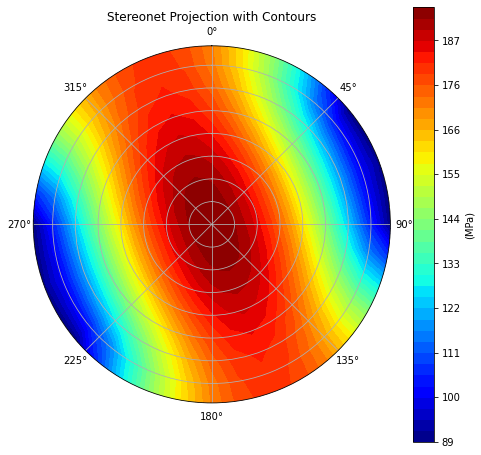

In [341]:
# Create a fault object Sv, S_hmax, S_hmin,Pp,mu,azimuth_shmin,azimuth_shmax,PR,Pw
Fault = fault(70, 105, 55, 32, 0.8, 340, 70, 0.3, 32)

# Create a meshgrid for all possible strikes (0 to 360) and dips (0 to 90)
azimut = np.arange(0, 361, 10)
devi = np.arange(0, 91, 10)
ST, DP = np.meshgrid(azimut, devi, indexing='ij')

# Initialize an empty matrix to store UCS val
z = np.zeros(ST.shape)

for i in range(ST.shape[0]):
    for j in range(ST.shape[1]):
        azi = ST[i, j]
        inc = DP[i, j]

        # Calculate Mud weight for each coordinate
        values = UCS_analisis(azi, inc, Fault)
        z[i, j] = np.max(values)  # max Mud weight at this coordinate PENTING!!!!

# Create a Stereonet projection using Matplotlib
fig, ax = plt.subplots(subplot_kw={'polar': True}, figsize=(8, 8))

# Adjust levels for contour plot
levels = np.linspace(z.min(), z.max(), 40)  # You can adjust the number 20 to change contour levels

cax = ax.contourf(np.radians(ST), np.radians(DP), z, cmap='jet', levels=levels)
ax.set_title('Stereonet Projection with Contours')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.grid(True)

# If you want to remove radial lines
ax.set_yticklabels([])

plt.colorbar(cax, ax=ax, format='%d', label='(MPa)')
plt.show()